# Chicago City Service Data Analysis
The goal of this analysis is to explore Chicago's 311 service request data and uncover insights about how the city responds to its residents.

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load dataset
df = pd.read_csv("../data/311_Service_Requests_20260518.csv")
df.shape

(752747, 39)

The original dataset includes requests created after the launch of the new 311 system on 12/18/2018 and some records from the previous system, indicated in the LEGACY_RECORD column. 

I saved a subset of the data, and only included the requests made in 2026 so far (up until May 17).

Additional information about the dataset and the original data can be found [here](https://data.cityofchicago.org/Service-Requests/311-Service-Requests/v6vf-nfxy/about_data).

In [3]:
# Display dataframe info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 752747 entries, 0 to 752746
Data columns (total 39 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SR_NUMBER                 752747 non-null  str    
 1   SR_TYPE                   752747 non-null  str    
 2   SR_SHORT_CODE             752747 non-null  str    
 3   CREATED_DEPARTMENT        395291 non-null  str    
 4   OWNER_DEPARTMENT          752747 non-null  str    
 5   STATUS                    752747 non-null  str    
 6   ORIGIN                    752448 non-null  str    
 7   CREATED_DATE              752747 non-null  str    
 8   LAST_MODIFIED_DATE        752747 non-null  str    
 9   CLOSED_DATE               694882 non-null  str    
 10  STREET_ADDRESS            752062 non-null  str    
 11  CITY                      673334 non-null  str    
 12  STATE                     673334 non-null  str    
 13  ZIP_CODE                  653449 non-null  float64
 14 

I'll be selecting a subset of columns to focus my analysis on.

In [4]:
# List of columns to keep
columns_to_keep = [
    "SR_NUMBER", "SR_TYPE", "STATUS", "CREATED_DATE", "CLOSED_DATE", "CREATED_HOUR", 
    "CREATED_DAY_OF_WEEK", "CREATED_MONTH", "WARD", "COMMUNITY_AREA", "OWNER_DEPARTMENT",
    "ORIGIN", "DUPLICATE", "LATITUDE", "LONGITUDE"
    ]

# Create new dataframe with only the specified columns
requests_df = df[columns_to_keep].copy()

requests_df.head()

,SR_NUMBER,SR_TYPE,STATUS,CREATED_DATE,CLOSED_DATE,CREATED_HOUR,CREATED_DAY_OF_WEEK,CREATED_MONTH,WARD,COMMUNITY_AREA,OWNER_DEPARTMENT,ORIGIN,DUPLICATE,LATITUDE,LONGITUDE
0,SR26-00000922,311 INFORMATION ONLY CALL,Completed,01/01/2026 10:37:34 AM,01/01/2026 10:37:34 AM,10,5,1,28.0,28.0,311 City Services,Phone Call,False,41.871834,-87.679845
1,SR26-00000924,Snow – Uncleared Sidewalk Complaint,Completed,01/01/2026 10:38:20 AM,01/05/2026 01:34:38 PM,10,5,1,15.0,61.0,CDOT - Department of Transportation,Internet,False,41.811471,-87.662903
2,SR26-00000925,311 INFORMATION ONLY CALL,Completed,01/01/2026 10:38:27 AM,01/01/2026 10:38:27 AM,10,5,1,28.0,28.0,311 City Services,Phone Call,False,41.871834,-87.679845
3,SR26-00000926,311 INFORMATION ONLY CALL,Completed,01/01/2026 10:38:29 AM,01/01/2026 10:38:30 AM,10,5,1,28.0,28.0,311 City Services,Phone Call,False,41.871834,-87.679845
4,SR26-00000927,311 INFORMATION ONLY CALL,Completed,01/01/2026 10:38:30 AM,01/01/2026 10:38:30 AM,10,5,1,28.0,28.0,311 City Services,Phone Call,False,41.871834,-87.679845


The dataset conveniently contains a "DUPLICATE" column (which we have included in our new df) that indicates wether a given request/record has a duplicate. We can use it to filter those out (where DUPLICATE == True) and create a new df containing only unique observations. 

In [5]:
# Remove rows where DUPLICATE is True
unique_requests_df = requests_df[~requests_df["DUPLICATE"]].copy() # same as requests_df[requests_df["DUPLICATE"] == False].copy()

# Display number of rows removed 
rows_removed = len(requests_df) - len(unique_requests_df)
print("Number of duplicate rows removed:", rows_removed)

Number of duplicate rows removed: 33321


### Looking Into Request Types

In [6]:
# Count occurences of each service request type
request_type_counts = unique_requests_df["SR_TYPE"].value_counts()
request_type_counts.head(10) # show 10 most common types of requests

SR_TYPE
311 INFORMATION ONLY CALL                       250606
Aircraft Noise Complaint                        151747
Graffiti Removal Request                         35451
Tree Trim Request (NO LONGER BEING ACCEPTED)     24605
Pothole in Street Complaint                      22950
Abandoned Vehicle Complaint                      20639
Garbage Cart Maintenance                         16996
Rodent Baiting/Rat Complaint                     12699
Street Light Out Complaint                       11278
Traffic Signal Out Complaint                      9201
Name: count, dtype: int64

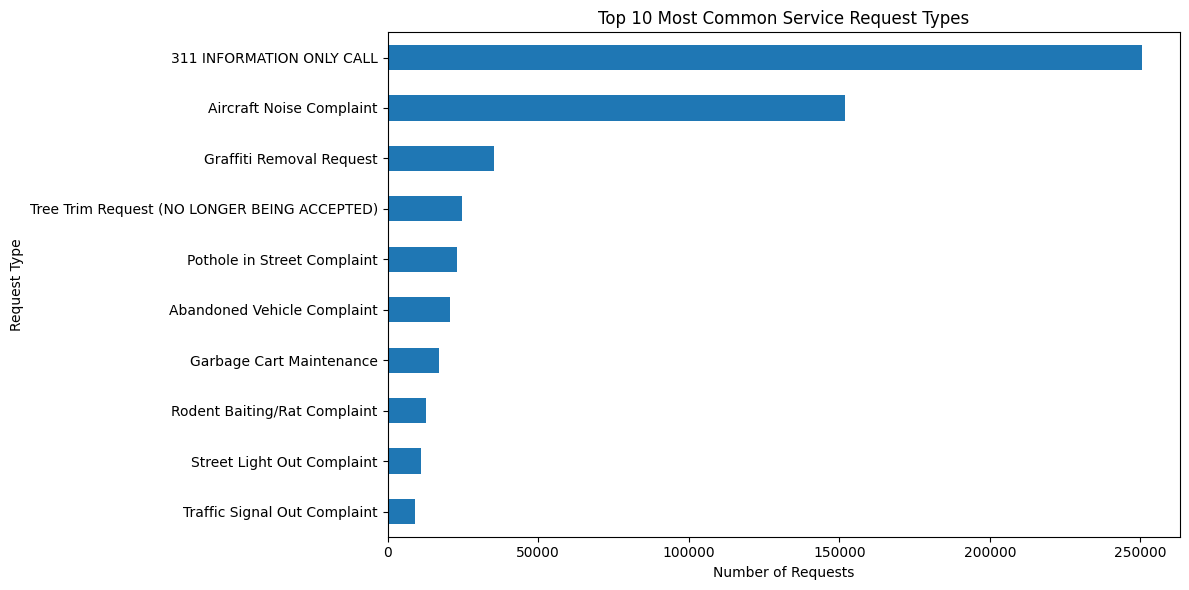

In [7]:
# Create plot figure
plt.figure(figsize=(12, 6))

# Horizontal bar chart
request_type_counts.head(10).sort_values().plot(kind="barh")

# Labels and title
plt.xlabel("Number of Requests")
plt.ylabel("Request Type")
plt.title("Top 10 Most Common Service Request Types")

# Clean layout
plt.tight_layout()

# Show plot
plt.show()

### Looking Into Request Origin Types

In [8]:
# Count number of requests by origin type
origin_counts = unique_requests_df["ORIGIN"].value_counts()
origin_counts

ORIGIN
Phone Call                    367613
Internet                      215954
Mobile Device                  71918
Mass Entry                     42220
Alderman's Office               9976
Generated In House              3130
Salesforce Mobile App           2916
SPOTCSR                         2182
DWM                             1925
WOFromTerraGo                    504
spot-open311-Chicago+Works       181
Walk-in                          169
E-Mail                           167
City Department                  141
spot-open311-CHITEXT              79
Mail                              21
HealthProfessionals               12
State Representatives              9
Phone                              5
Fax                                4
Chicago Fire Department            4
Chicago Police Department          3
FY25 Budget Engagement             2
SPOT311                            1
Name: count, dtype: int64

### Requests on Different Hours ofthe Day

In [9]:
# Count number of requests by hour of the day and sort by hour
hourly_counts = unique_requests_df["CREATED_HOUR"].value_counts().sort_index()
hourly_counts

CREATED_HOUR
0      9572
1      6346
2      5035
3      4048
4      5093
5      6586
6     16514
7     33384
8     41506
9     46129
10    44875
11    46101
12    47883
13    50285
14    54010
15    50627
16    45024
17    39637
18    35485
19    34368
20    31778
21    28887
22    21996
23    14257
Name: count, dtype: int64

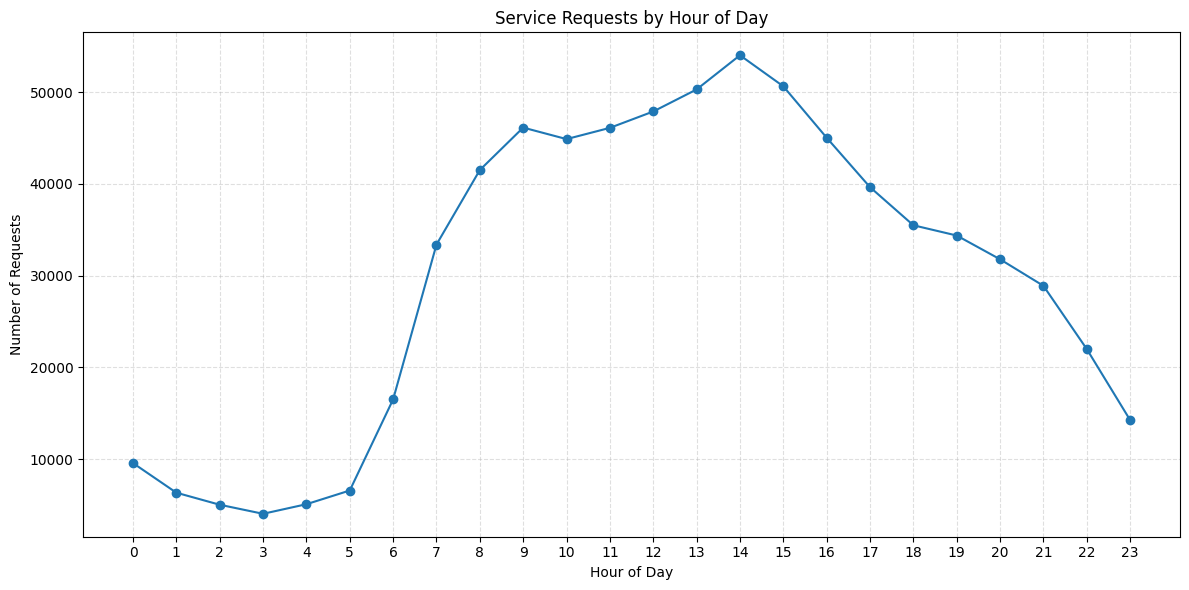

In [10]:
# Create plot figure
plt.figure(figsize=(12, 6))

# Line plot 
plt.plot(hourly_counts.index, hourly_counts.values, marker="o")

# Labels and title
plt.xlabel("Hour of Day")
plt.ylabel("Number of Requests")
plt.title("Service Requests by Hour of Day")

# Show every hour 
plt.xticks(range(24))

# Add subtle grid
plt.grid(True, linestyle="--", alpha=0.4)

# Clean layout
plt.tight_layout()

# Show plot
plt.show()

### Requests on the Different Days of the Week

In [11]:
sorted(unique_requests_df["CREATED_DAY_OF_WEEK"].unique())

[np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7)]

The "CREATED_DAY_OF_WEEK" column features a number for each day of the week. We'll want to map the numbers to the actual names of the days for easier inspection.

In [12]:
# Map numbers to day names
day_name_map = {
    1: "Sunday",
    2: "Monday",
    3: "Tuesday",
    4: "Wednesday",
    5: "Thursday",
    6: "Friday",
    7: "Saturday"
}

# Count requests by day of the week
day_counts = unique_requests_df["CREATED_DAY_OF_WEEK"].value_counts().sort_index()

# Replace numbers with day names
day_counts.index = day_counts.index.map(day_name_map)

day_counts

CREATED_DAY_OF_WEEK
Sunday        81881
Monday       112538
Tuesday      110315
Wednesday    109693
Thursday     113882
Friday       113197
Saturday      77920
Name: count, dtype: int64

### Looking Into Owner Departments

In [13]:
# Count number of requests by owner department
department_counts = unique_requests_df["OWNER_DEPARTMENT"].value_counts()
department_counts.head(10)

OWNER_DEPARTMENT
311 City Services                                  250606
Streets and Sanitation                             171420
Aviation                                           151747
CDOT - Department of Transportation                 69873
DWM - Department of Water Management                28077
DOB - Buildings                                     14693
Animal Care and Control                             12842
Finance                                              7960
Outside Agencies                                     4781
BACP - Business Affairs and Consumer Protection      4289
Name: count, dtype: int64

### Departments With Longest Average Close Time
In order to see which departments have the longer close time for requests, we first need to convert the date columns to datetime to easily calculate the time between the open and close of a request easily.
Then we'll group the resulting closing times by owner department.

In [14]:
# Convert date columns to datetime
unique_requests_df["CREATED_DATE"] = pd.to_datetime(unique_requests_df["CREATED_DATE"], errors="coerce")
unique_requests_df["CLOSED_DATE"] = pd.to_datetime(unique_requests_df["CLOSED_DATE"], errors="coerce")

# Calculate days to close
unique_requests_df["DAYS_TO_CLOSE"] = (unique_requests_df["CLOSED_DATE"] - unique_requests_df["CREATED_DATE"]).dt.total_seconds() / (24 * 3600)


In [18]:
unique_requests_df["DAYS_TO_CLOSE"].sample(10)

302728     0.000000
679512          NaN
365473    47.086921
141816     0.000000
236929     0.000012
46323      2.356250
729092     0.795405
56296      3.206910
451623     0.000012
675885     0.000012
Name: DAYS_TO_CLOSE, dtype: float64

In [ ]:
# Group by OWNER_DEPARTMENT and calculate average days to close
department_avg_close_time = unique_requests_df.groupby("OWNER_DEPARTMENT")["DAYS_TO_CLOSE"].mean().sort_values(ascending=False)
department_avg_close_time

OWNER_DEPARTMENT
DOB - Buildings                                    21.243770
BACP - Business Affairs and Consumer Protection    16.149676
Health                                             15.660101
Fire                                               11.512892
City Clerk's Office                                 7.261540
DWM - Department of Water Management                6.616236
CDOT - Department of Transportation                 6.438655
Streets and Sanitation                              5.403121
Department of Housing                               4.698315
Animal Care and Control                             4.274605
Outside Agencies                                    0.132667
Finance                                             0.000005
311 City Services                                   0.000005
Aviation                                            0.000005
Name: DAYS_TO_CLOSE, dtype: float64

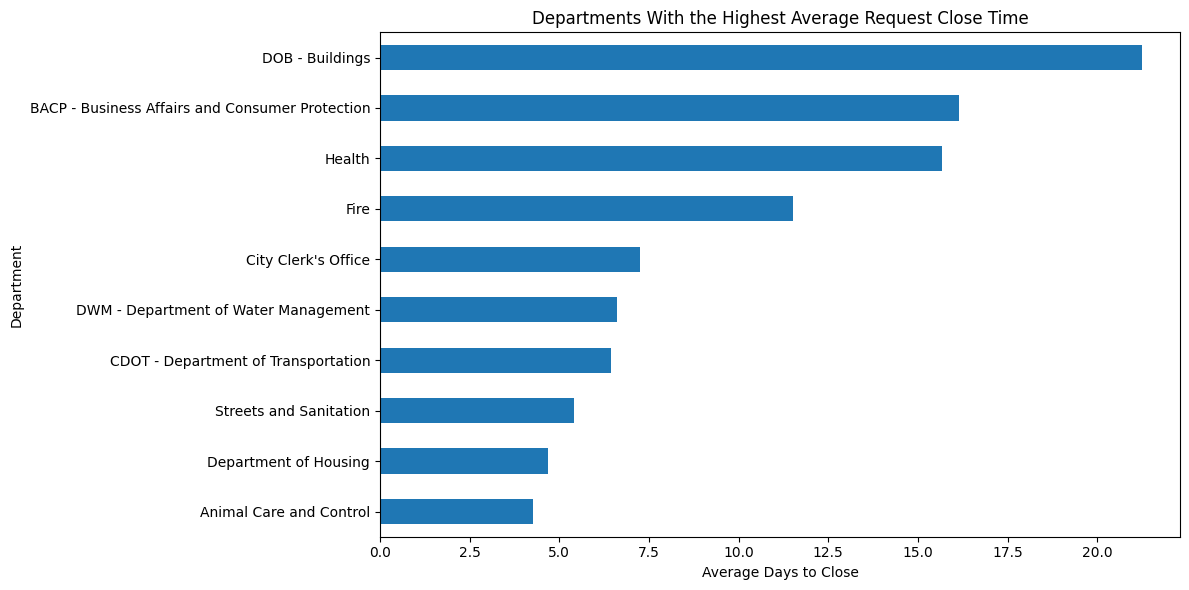

In [19]:
# Create figure
plt.figure(figsize=(12, 6))

# Horizontal bar chart (of 10 departments with the highest close time on avg)
department_avg_close_time.head(10).sort_values().plot(kind="barh")

# Labels and title
plt.xlabel("Average Days to Close")
plt.ylabel("Department")
plt.title("Departments With the Highest Average Request Close Time")

# Clean layout
plt.tight_layout()

# Show plot
plt.show()

Now let's use the median and compare both, to account for extreme outliers like requests that were forgotten and left open for potentially hundreds of days

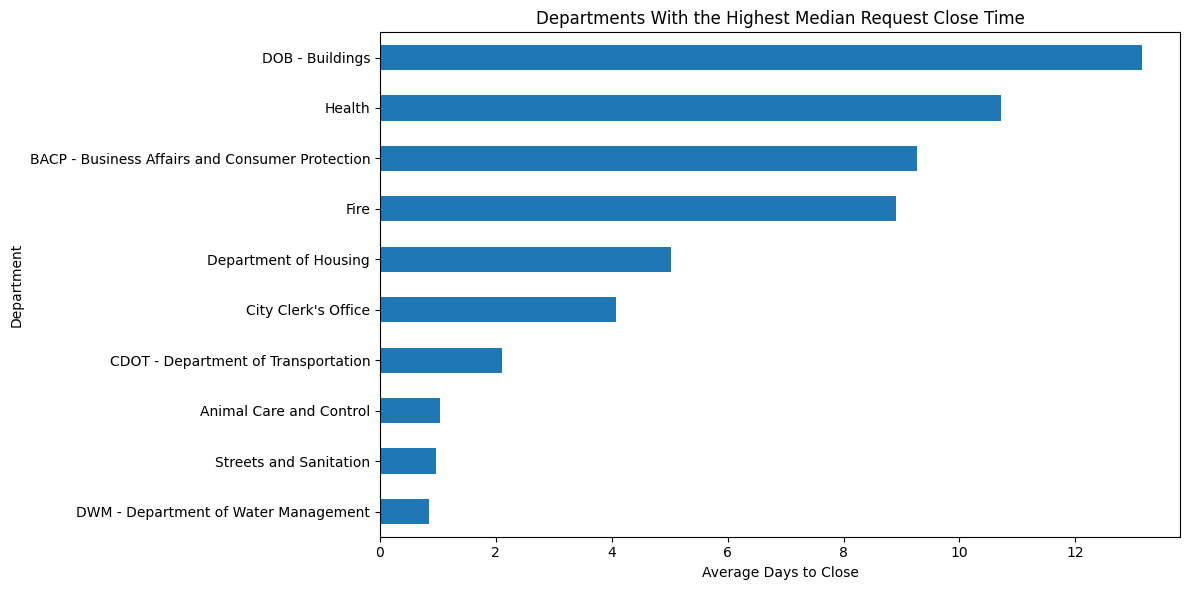

In [22]:
# Same process for the median
department_median_close_time = unique_requests_df.groupby("OWNER_DEPARTMENT")["DAYS_TO_CLOSE"].median().sort_values(ascending=False)

plt.figure(figsize=(12, 6))

department_median_close_time.head(10).sort_values().plot(kind="barh")

plt.xlabel("Average Days to Close")
plt.ylabel("Department")
plt.title("Departments With the Highest Median Request Close Time")

plt.tight_layout()

plt.show()


We can see the mean and median close times show similar trends overall, with DOB - Buildings consistently having the longest request resolution times. However, some departments show noticeable differences between the mean and median values, suggesting the presence of outliers or unusually long-running requests that inflate the average close time.